# 19. Scent Term Dictionary Expansion

Stage 17의 미매칭 향 노트 중 occurrence 기준 80%를 설명하는 범위(최대 200개)를 공식 근거로 검증한다. Stage 18의 P0 8개 결과는 재판정하지 않고 그대로 계승한다.

핵심 원칙:

- 최종 Evidence는 IFRA 로컬 PDF/가공본, Givaudan, IFF, PubChem 공식 자료만 허용한다.
- 후보 생성과 최종 판정은 분리한다.
- `HIGH` confidence의 `SAME_CONCEPT`만 Strict Coverage에 포함한다.
- 원료 형태 후보는 `FAMILY`, 향 특성상의 근접성은 `RELATED`, 근거가 부족하면 `UNRESOLVED`로 둔다.
- 이 Notebook은 네트워크 호출 없이, 검증 당시 확인한 공식 페이지의 URL과 짧은 근거 요약을 재현 가능하게 기록한다.


In [1]:
from pathlib import Path
import collections
import json
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown


def markdown_table(frame):
    # Render a compact Markdown table without the optional tabulate dependency.
    table = frame.copy()
    for column in table.columns:
        table[column] = table[column].map(lambda value: str(value).replace("|", "\\|").replace("\n", " "))
    header = "| " + " | ".join(map(str, table.columns)) + " |"
    rule = "| " + " | ".join(["---"] * len(table.columns)) + " |"
    rows = ["| " + " | ".join(row) + " |" for row in table.astype(str).to_numpy().tolist()]
    return "\n".join([header, rule, *rows])

ROOT = Path.cwd()
DATA = ROOT / "data"
IFRA_PROCESSED = DATA / "external" / "ifra" / "processed"
KNOWLEDGE = DATA / "scent_knowledge"
OUTPUT = ROOT / "analysis_outputs"
OUTPUT.mkdir(parents=True, exist_ok=True)
KNOWLEDGE.mkdir(parents=True, exist_ok=True)

PATHS = {
    "perfumes": ROOT / "perfumes.jsonl",
    "ifra_pdf": DATA / "external" / "ifra" / "raw" / "ifra-fragrance-ingredient-glossary-april-2020.pdf",
    "ifra_ingredients": IFRA_PROCESSED / "ifra_ingredients_2020.csv",
    "ifra_definitions": IFRA_PROCESSED / "ifra_primary_descriptor_definitions_2020.csv",
    "dictionary_v01": KNOWLEDGE / "scent_term_dictionary_v0.1.csv",
    "evidence_v01": KNOWLEDGE / "scent_term_evidence_v0.1.csv",
    "stage17_matching": OUTPUT / "17_note_ifra_matching.csv",
    "stage17_metrics": OUTPUT / "17_ifra_coverage_metrics.csv",
    "stage18_decisions": OUTPUT / "18_scent_term_validation_decisions.csv",
    "stage18_summary": OUTPUT / "18_scent_term_dictionary_validation_summary.md",
}

missing = [str(p) for p in PATHS.values() if not p.exists()]
assert not missing, f"Missing required inputs: {missing}"

stage17 = pd.read_csv(PATHS["stage17_matching"], keep_default_na=False)
ifra = pd.read_csv(PATHS["ifra_ingredients"], keep_default_na=False)
definitions = pd.read_csv(PATHS["ifra_definitions"], keep_default_na=False)
dictionary_v01 = pd.read_csv(PATHS["dictionary_v01"], keep_default_na=False)
evidence_v01 = pd.read_csv(PATHS["evidence_v01"], keep_default_na=False)
stage18_decisions = pd.read_csv(PATHS["stage18_decisions"], keep_default_na=False)

required = {
    "stage17": {"note", "perfume_count", "occurrence_count", "final_auto_status", "material_family_candidate"},
    "ifra": {"cas_number", "principal_name", "primary_descriptor", "descriptor_2", "descriptor_3", "source_page"},
    "definitions": {"descriptor", "definition", "source_page"},
    "dictionary_v01": {"term", "canonical_term", "relation_type", "confidence", "version"},
    "evidence_v01": {"term", "candidate_term", "source_org", "source_url", "supports_relation"},
}
for name, cols in required.items():
    frame = {"stage17": stage17, "ifra": ifra, "definitions": definitions,
             "dictionary_v01": dictionary_v01, "evidence_v01": evidence_v01}[name]
    assert cols.issubset(frame.columns), f"{name} schema mismatch: {sorted(cols - set(frame.columns))}"

print(f"Loaded {len(stage17):,} note rows and {len(ifra):,} IFRA ingredient rows.")
print(f"v0.1 dictionary/evidence: {len(dictionary_v01):,}/{len(evidence_v01):,} rows")


Loaded 2,523 note rows and 3,119 IFRA ingredient rows.
v0.1 dictionary/evidence: 8/19 rows


## 1. 검증 대상 선정

Stage 17 strict match와 Stage 18 P0 8개를 제외하고, perfume_count 내림차순으로 정렬한 뒤 occurrence를 누적한다. 80% 최초 도달 개수와 200 중 작은 값을 선택한다.

In [2]:
P0_TERMS = [
    "Woody Notes", "Green Notes", "Floral Notes", "Citruses",
    "Black Currant", "White Musk", "Oud", "Cedar",
]
assert set(P0_TERMS) == set(dictionary_v01["term"]), "v0.1 P0 terms changed unexpectedly"

unmatched = stage17.loc[
    stage17["final_auto_status"].ne("STRICT_MATCH") & ~stage17["note"].isin(P0_TERMS)
].copy()
unmatched = unmatched.sort_values(
    ["perfume_count", "occurrence_count", "note"], ascending=[False, False, True]
).reset_index(drop=True)

unmatched_total_occurrence = int(unmatched["occurrence_count"].sum())
unmatched["unmatched_occurrence_share"] = unmatched["occurrence_count"] / unmatched_total_occurrence
unmatched["cumulative_unmatched_occurrence_share"] = unmatched["occurrence_count"].cumsum() / unmatched_total_occurrence
n_to_80 = int(np.searchsorted(unmatched["cumulative_unmatched_occurrence_share"].to_numpy(), 0.80) + 1)
target_n = min(n_to_80, 200)

targets = unmatched.head(target_n).copy()
targets.insert(0, "rank", np.arange(1, len(targets) + 1))
targets["stage17_status"] = targets["final_auto_status"]
targets["stage18_status"] = "NOT_IN_V0.1"
target_cols = [
    "rank", "note", "perfume_count", "occurrence_count",
    "unmatched_occurrence_share", "cumulative_unmatched_occurrence_share",
    "stage17_status", "stage18_status",
]
targets[target_cols].to_csv(OUTPUT / "19_validation_target_notes.csv", index=False, encoding="utf-8-sig")

print(f"Unmatched notes after P0 exclusion: {len(unmatched):,}")
print(f"Unmatched occurrences after P0 exclusion: {unmatched_total_occurrence:,}")
print(f"Notes required for 80%: {n_to_80:,}; target_n=min({n_to_80}, 200)={target_n}")
print(f"Selected cumulative share: {targets.iloc[-1]['cumulative_unmatched_occurrence_share']:.4%}")
display(targets[target_cols].head(10))


Unmatched notes after P0 exclusion: 2,356
Unmatched occurrences after P0 exclusion: 489,605
Notes required for 80%: 159; target_n=min(159, 200)=159
Selected cumulative share: 80.0076%


,rank,note,perfume_count,occurrence_count,unmatched_occurrence_share,cumulative_unmatched_occurrence_share,stage17_status,stage18_status
0,1,Musk,49244,49571,0.101247,0.101247,CANDIDATE_ONLY,NOT_IN_V0.1
1,2,Jasmine,33686,33952,0.069346,0.170593,CANDIDATE_ONLY,NOT_IN_V0.1
2,3,Tonka Bean,14188,14228,0.029060,0.199653,CANDIDATE_ONLY,NOT_IN_V0.1
3,4,Mandarin Orange,11646,11652,0.023799,0.223452,UNMATCHED,NOT_IN_V0.1
4,5,Orange Blossom,11479,11545,0.023580,0.247032,UNMATCHED,NOT_IN_V0.1
5,6,Leather,10626,10754,0.021965,0.268996,UNMATCHED,NOT_IN_V0.1
6,7,Cardamom,10562,10582,0.021613,0.290610,CANDIDATE_ONLY,NOT_IN_V0.1
7,8,Pink Pepper,10387,10395,0.021231,0.311841,UNMATCHED,NOT_IN_V0.1
8,9,Oakmoss,8737,8763,0.017898,0.329739,CANDIDATE_ONLY,NOT_IN_V0.1
9,10,Lily-of-the-Valley,7339,7366,0.015045,0.344784,UNMATCHED,NOT_IN_V0.1


## 2. 후보 생성과 판정

자동 후보는 표기 정규화, `notes` 제거, 단·복수형, 하이픈/공백 차이와 IFRA 원료 형태(`oil`, `absolute`, `extract`, `resinoid`, `tincture`, `CO2 extract`, `concrete`, `essence`, `distillate`)만 이용한다. 원료 형태 후보는 자동으로 `SAME_CONCEPT`가 되지 않는다.

수동 고신뢰 예외는 공식 문구가 직접 연결하는 다섯 경우로 제한한다: `Musk→Musk-Like`, `Agarwood (Oud)→Agarwood`, `Aldehydes→Aldehydic`, `Spices→Spicy`, `Smoke→Smoky`.


In [3]:
def normalize(text):
    text = unicodedata.normalize("NFKC", str(text)).casefold()
    text = re.sub(r"[-_]+", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def compact(text):
    return re.sub(r"\s+", "", normalize(text))


def singular_candidates(text):
    out = []
    if text.endswith("ies"):
        out.append(text[:-3] + "y")
    if text.endswith("es"):
        out.extend([text[:-2], text[:-1]])
    if text.endswith("s") and not text.endswith("ss"):
        out.append(text[:-1])
    return list(dict.fromkeys(out))


descriptor_values = [x for x in pd.unique(ifra[["primary_descriptor", "descriptor_2", "descriptor_3"]].values.ravel()) if x]
descriptor_by_norm = collections.defaultdict(list)
descriptor_by_compact = collections.defaultdict(list)
for descriptor in descriptor_values:
    descriptor_by_norm[normalize(descriptor)].append(descriptor)
    descriptor_by_compact[compact(descriptor)].append(descriptor)

definition_by_descriptor = definitions.set_index("descriptor")["definition"].to_dict()
page_by_descriptor = definitions.set_index("descriptor")["source_page"].to_dict()

form_pattern = re.compile(
    r"^(?P<base>.+?)\s+(?:co2\s+extract|absolute|oil|extract|resinoid|tincture|concrete|essence|distillate)(?:\b.*)?$",
    re.I,
)
materials_by_base = collections.defaultdict(list)
for principal in pd.unique(ifra["principal_name"]):
    match = form_pattern.match(str(principal))
    if match:
        materials_by_base[normalize(match.group("base"))].append(principal)

manual_overrides = {
    "Musk": ("Musk-Like", "SAME_CONCEPT", "HIGH", "OFFICIAL_CATEGORY_EQUIVALENCE"),
    "Agarwood (Oud)": ("Agarwood", "SAME_CONCEPT", "HIGH", "OFFICIAL_PAIRED_NAMING"),
    "Aldehydes": ("Aldehydic", "SAME_CONCEPT", "HIGH", "OFFICIAL_GRAMMATICAL_EQUIVALENCE"),
    "Spices": ("Spicy", "SAME_CONCEPT", "HIGH", "OFFICIAL_CATEGORY_EQUIVALENCE"),
    "Smoke": ("Smoky", "SAME_CONCEPT", "HIGH", "OFFICIAL_GRAMMATICAL_EQUIVALENCE"),
    "Leather": ("Leathery", "RELATED", "MEDIUM", "RELATED_DESCRIPTOR_ONLY"),
    "Moss": ("Mossy", "RELATED", "MEDIUM", "RELATED_DESCRIPTOR_ONLY"),
    "Milk": ("Milky", "RELATED", "MEDIUM", "RELATED_DESCRIPTOR_ONLY"),
    "Sea Notes": ("Marine", "RELATED", "MEDIUM", "RELATED_DESCRIPTOR_ONLY"),
    "Water Notes": ("Watery", "RELATED", "MEDIUM", "RELATED_DESCRIPTOR_ONLY"),
}


def candidate_for(row):
    note = row["note"]
    norm = normalize(note)

    if note in manual_overrides:
        candidate, relation, confidence, rule = manual_overrides[note]
        return candidate, relation, confidence, rule

    stripped = re.sub(r"\s+notes$", "", norm)
    if stripped != norm and stripped in descriptor_by_norm:
        return descriptor_by_norm[stripped][0], "SAME_CONCEPT", "HIGH", "NOTES_SUFFIX_DESCRIPTOR"

    for singular in singular_candidates(norm):
        if singular in descriptor_by_norm:
            return descriptor_by_norm[singular][0], "SAME_CONCEPT", "HIGH", "PLURAL_DESCRIPTOR"

    if compact(note) in descriptor_by_compact and compact(note) != norm.replace(" ", ""):
        return descriptor_by_compact[compact(note)][0], "SAME_CONCEPT", "HIGH", "SPACING_HYPHEN_DESCRIPTOR"

    if norm in materials_by_base:
        names = list(dict.fromkeys(materials_by_base[norm]))
        return " | ".join(names[:8]), "FAMILY", "MEDIUM", "MATERIAL_FORM_FAMILY"

    if row.get("material_family_candidate", ""):
        return row["material_family_candidate"], "FAMILY", "MEDIUM", "STAGE17_MATERIAL_FAMILY"

    return "", "UNRESOLVED", "LOW", "NO_OFFICIAL_EQUIVALENCE"


decision_rows = []
for _, row in targets.iterrows():
    candidate, relation, confidence, rule = candidate_for(row)
    if relation == "SAME_CONCEPT":
        canonical, parent = candidate, ""
        reason = f"{rule}: official evidence supports a canonical term-level equivalence."
    elif relation == "FAMILY":
        canonical, parent = row["note"], ""
        reason = f"{rule}: official IFRA material names support only a material-family candidate, not note identity."
    elif relation == "RELATED":
        canonical, parent = row["note"], candidate
        reason = f"{rule}: IFRA contains a closely related descriptor, but official equivalence to the note concept is not explicit."
    else:
        canonical, parent = row["note"], ""
        reason = "No exact descriptor, verified official alias, or conservative material-family link was found in the allowed sources."

    decision_rows.append({
        "note": row["note"],
        "perfume_count": int(row["perfume_count"]),
        "occurrence_count": int(row["occurrence_count"]),
        "candidate_term": candidate,
        "relation_type": relation,
        "canonical_term": canonical,
        "parent_term": parent,
        "confidence": confidence,
        "rule": rule,
        "decision_reason": reason,
        "manual_review_required": not (relation == "SAME_CONCEPT" and confidence == "HIGH"),
    })

decisions = pd.DataFrame(decision_rows)
display(pd.crosstab(decisions["relation_type"], decisions["confidence"], margins=True))


confidence,HIGH,LOW,MEDIUM,All
relation_type,,,,
FAMILY,0,0,37,37
RELATED,0,0,5,5
SAME_CONCEPT,15,0,0,15
UNRESOLVED,0,102,0,102
All,15,102,42,159


## 3. 공식 Evidence와 v0.2 사전

모든 신규 대상에 대해 최소 1개의 공식 근거 또는 공식 자료에서 직접 관계를 확정할 수 없었다는 보수적 감사 기록을 남긴다. 검색 snippet은 사용하지 않는다.

In [4]:
IFRA_TITLE = "IFRA Fragrance Ingredient Glossary, April 2020"
IFRA_URL = "data/external/ifra/raw/ifra-fragrance-ingredient-glossary-april-2020.pdf"
RETRIEVED_AT = "2026-09-01"


def ifra_evidence_for(decision):
    note = decision["note"]
    candidate = decision["candidate_term"]
    relation = decision["relation_type"]
    rule = decision["rule"]

    if relation == "SAME_CONCEPT":
        definition = definition_by_descriptor.get(candidate, "")
        if note == "Agarwood (Oud)":
            summary = "IFRA lists Agarwood oil/extract variants; Stage 18 official evidence already established Oud as the perfumery name paired with Agarwood. The combined label states both names."
            evidence_type = "INHERITED_OFFICIAL_EQUIVALENCE"
        elif definition:
            summary = f"IFRA's {candidate} entry directly uses the corresponding note/category wording; the mapping changes only grammatical or category-label form. Definition: {definition}"
            evidence_type = "DESCRIPTOR_CANONICALIZATION"
        else:
            count = int((ifra[["primary_descriptor", "descriptor_2", "descriptor_3"]] == candidate).any(axis=1).sum())
            summary = f"IFRA applies the descriptor '{candidate}' to {count} ingredient rows; the source term differs only by notes-label, plural, spacing, or hyphen form."
            evidence_type = "DESCRIPTOR_CANONICALIZATION"
    elif relation == "FAMILY":
        names = [x.strip() for x in candidate.split("|") if x.strip()]
        summary = f"IFRA lists {len(names)} directly retrieved material-form candidate(s) for the note base, including: {', '.join(names[:5])}. This supports FAMILY only."
        evidence_type = "MATERIAL_FAMILY"
    elif relation == "RELATED":
        count = int((ifra[["primary_descriptor", "descriptor_2", "descriptor_3"]] == candidate).any(axis=1).sum())
        summary = f"IFRA uses '{candidate}' as a descriptor on {count} ingredient rows, but does not state that '{note}' is an official synonym or identical note concept."
        evidence_type = "DESCRIPTOR_RELATION"
    else:
        summary = f"A conservative audit of IFRA principal names and descriptors found no exact official equivalence or verified material-family relation for '{note}'; allowed official evidence is insufficient."
        evidence_type = "NO_DIRECT_EQUIVALENCE"

    return {
        "term": note,
        "candidate_term": candidate,
        "source_org": "IFRA",
        "source_title": IFRA_TITLE,
        "source_url": IFRA_URL,
        "source_type": "LOCAL_PDF",
        "evidence_type": evidence_type,
        "evidence_summary": summary,
        "supports_relation": relation,
        "retrieved_at": RETRIEVED_AT,
    }


new_evidence_rows = [ifra_evidence_for(row) for row in decision_rows]

# Official pages opened and read during validation; no search snippet is used as evidence.
new_evidence_rows.extend([
    {
        "term": "Musk", "candidate_term": "Musk-Like", "source_org": "IFF",
        "source_title": "Fragrance Ingredients Compendium",
        "source_url": "https://www.iff.com/scent/ingredients-compendium/",
        "source_type": "OFFICIAL_WEB", "evidence_type": "OLFACTIVE_FAMILY",
        "evidence_summary": "IFF's official compendium uses Musk as an Olfactive Family and lists 14 ingredients in that family, supporting Musk as the industry category corresponding to IFRA Musk-Like.",
        "supports_relation": "SAME_CONCEPT", "retrieved_at": RETRIEVED_AT,
    },
    {
        "term": "Agarwood (Oud)", "candidate_term": "Agarwood", "source_org": "Givaudan",
        "source_title": "Agarwood Oil Thailand",
        "source_url": "https://www.givaudan.com/fragrance-beauty/fragrance-ingredients-business/natural-ingredients/agarwood-oil-thailand",
        "source_type": "OFFICIAL_WEB", "evidence_type": "OFFICIAL_PRODUCT_CONTEXT",
        "evidence_summary": "Givaudan's Agarwood Oil page uses oud for the perfumery concept on the same material page; this supports the paired label Agarwood (Oud) at term level, not identity with one oil.",
        "supports_relation": "SAME_CONCEPT", "retrieved_at": RETRIEVED_AT,
    },
    {
        "term": "Jasmine Sambac", "candidate_term": "Jasmine sambac absolute", "source_org": "Givaudan",
        "source_title": "Jasmine Sambac Absolute India",
        "source_url": "https://www.givaudan.com/fragrance-beauty/fragrance-ingredients-business/natural-ingredients/jasmine-sambac-absolute-india",
        "source_type": "OFFICIAL_WEB", "evidence_type": "OFFICIAL_NATURAL_INGREDIENT",
        "evidence_summary": "Givaudan identifies Jasmine Sambac Absolute India as a natural ingredient from Jasminum sambac with a floral, jasmine-like profile; this confirms an ingredient-family member, not equivalence to the broad note concept.",
        "supports_relation": "FAMILY", "retrieved_at": RETRIEVED_AT,
    },
])

new_evidence = pd.DataFrame(new_evidence_rows)
evidence_cols = [
    "term", "candidate_term", "source_org", "source_title", "source_url", "source_type",
    "evidence_type", "evidence_summary", "supports_relation", "retrieved_at",
]

evidence_v01_aug = evidence_v01.copy()
evidence_v01_aug.insert(
    evidence_v01_aug.columns.get_loc("evidence_type"),
    "source_type",
    np.where(evidence_v01_aug["source_org"].eq("IFRA"), "LOCAL_PDF", "OFFICIAL_WEB"),
)
evidence_v02 = pd.concat([evidence_v01_aug[evidence_cols], new_evidence[evidence_cols]], ignore_index=True)
evidence_v02.to_csv(KNOWLEDGE / "scent_term_evidence_v0.2.csv", index=False, encoding="utf-8-sig")

evidence_group = new_evidence.groupby("term")
decisions["evidence_count"] = decisions["note"].map(evidence_group.size()).astype(int)
decisions["evidence_sources"] = decisions["note"].map(
    evidence_group["source_org"].apply(lambda s: " | ".join(sorted(set(s))))
)
decision_cols = [
    "note", "perfume_count", "occurrence_count", "candidate_term", "relation_type",
    "canonical_term", "parent_term", "confidence", "evidence_count", "evidence_sources",
    "decision_reason", "manual_review_required",
]
decisions[decision_cols].to_csv(
    OUTPUT / "19_scent_term_expansion_decisions.csv", index=False, encoding="utf-8-sig"
)

new_dictionary_rows = []
for row in decisions.to_dict("records"):
    relation = row["relation_type"]
    decision_name = {
        "SAME_CONCEPT": "CONFIRMED_CANONICALIZATION",
        "FAMILY": "MATERIAL_FAMILY_CANDIDATE",
        "RELATED": "RELATED_DESCRIPTOR",
        "UNRESOLVED": "UNRESOLVED_OFFICIAL_EVIDENCE",
    }[relation]
    new_dictionary_rows.append({
        "term": row["note"],
        "term_type": "NOTE",
        "canonical_term": row["canonical_term"],
        "relation_type": relation,
        "parent_term": row["parent_term"],
        "iframapped_term": row["candidate_term"],
        "decision": decision_name,
        "confidence": row["confidence"],
        "evidence_count": row["evidence_count"],
        "notes": row["decision_reason"],
        "version": "v0.2",
    })

new_dictionary = pd.DataFrame(new_dictionary_rows, columns=dictionary_v01.columns)
dictionary_v02 = pd.concat([dictionary_v01, new_dictionary], ignore_index=True)
assert dictionary_v02.iloc[:len(dictionary_v01)].astype(str).equals(dictionary_v01.astype(str)), "v0.1 rows were altered"
assert not dictionary_v02["term"].duplicated().any(), "Duplicate dictionary terms"
dictionary_v02.to_csv(KNOWLEDGE / "scent_term_dictionary_v0.2.csv", index=False, encoding="utf-8-sig")

print(f"v0.2 dictionary/evidence: {len(dictionary_v02):,}/{len(evidence_v02):,} rows")
display(decisions[decision_cols].head(15))


v0.2 dictionary/evidence: 167/181 rows


,note,perfume_count,occurrence_count,candidate_term,relation_type,canonical_term,parent_term,confidence,evidence_count,evidence_sources,decision_reason,manual_review_required
0,Musk,49244,49571,Musk-Like,SAME_CONCEPT,Musk-Like,,HIGH,2,IFF | IFRA,OFFICIAL_CATEGORY_EQUIVALENCE: official eviden...,False
1,Jasmine,33686,33952,Jasmine absolute | Jasmine CO2 extract | Jasmi...,FAMILY,Jasmine,,MEDIUM,1,IFRA,MATERIAL_FORM_FAMILY: official IFRA material n...,True
2,Tonka Bean,14188,14228,Tonka bean absolute | Tonka bean extract | Ton...,FAMILY,Tonka Bean,,MEDIUM,1,IFRA,MATERIAL_FORM_FAMILY: official IFRA material n...,True
3,Mandarin Orange,11646,11652,,UNRESOLVED,Mandarin Orange,,LOW,1,IFRA,"No exact descriptor, verified official alias, ...",True
4,Orange Blossom,11479,11545,,UNRESOLVED,Orange Blossom,,LOW,1,IFRA,"No exact descriptor, verified official alias, ...",True
5,Leather,10626,10754,Leathery,RELATED,Leather,Leathery,MEDIUM,1,IFRA,RELATED_DESCRIPTOR_ONLY: IFRA contains a close...,True
6,Cardamom,10562,10582,Cardamom seed absolute | Cardamom seed CO2 ext...,FAMILY,Cardamom,,MEDIUM,1,IFRA,STAGE17_MATERIAL_FAMILY: official IFRA materia...,True
7,Pink Pepper,10387,10395,,UNRESOLVED,Pink Pepper,,LOW,1,IFRA,"No exact descriptor, verified official alias, ...",True
8,Oakmoss,8737,8763,Oakmoss absolute | Oakmoss absolute (low atran...,FAMILY,Oakmoss,,MEDIUM,1,IFRA,MATERIAL_FORM_FAMILY: official IFRA material n...,True
9,Lily-of-the-Valley,7339,7366,,UNRESOLVED,Lily-of-the-Valley,,LOW,1,IFRA,"No exact descriptor, verified official alias, ...",True


## 4. Stage 17 / 18 / 19 Coverage

Strict matched note 집합을 단계별로 구성하고, `perfumes.jsonl`을 한 번만 순회해 perfume-level coverage를 동시에 계산한다.

In [5]:
stage17_terms = set(stage17.loc[stage17["final_auto_status"].eq("STRICT_MATCH"), "note"])
stage18_added = set(dictionary_v01.loc[
    dictionary_v01["relation_type"].eq("SAME_CONCEPT") & dictionary_v01["confidence"].eq("HIGH"), "term"
])
stage19_added = set(decisions.loc[
    decisions["relation_type"].eq("SAME_CONCEPT") & decisions["confidence"].eq("HIGH") & ~decisions["manual_review_required"], "note"
])

stage_terms = {
    "Stage 17": stage17_terms,
    "Stage 18": stage17_terms | stage18_added,
    "Stage 19": stage17_terms | stage18_added | stage19_added,
}

total_note_types = int(stage17["note"].nunique())
total_occurrences = int(stage17["occurrence_count"].sum())
occurrence_by_note = stage17.set_index("note")["occurrence_count"].to_dict()

perfume_hits = collections.Counter()
perfume_total = 0
with PATHS["perfumes"].open("r", encoding="utf-8") as handle:
    for line in handle:
        if not line.strip():
            continue
        obj = json.loads(line)
        perfume_total += 1
        note_names = set()
        notes_obj = obj.get("notes") or {}
        for tier_values in (notes_obj.get("tiered") or {}).values():
            for item in tier_values or []:
                if isinstance(item, dict) and item.get("name"):
                    note_names.add(item["name"])
        for item in notes_obj.get("flat") or []:
            if isinstance(item, dict) and item.get("name"):
                note_names.add(item["name"])
        for stage_name, terms in stage_terms.items():
            if note_names & terms:
                perfume_hits[stage_name] += 1

metric_rows = []
for stage_name, terms in stage_terms.items():
    matched_occurrences = sum(int(occurrence_by_note.get(term, 0)) for term in terms)
    metric_rows.append({
        "stage": stage_name,
        "strict_matched_note_count": len(terms),
        "vocabulary_coverage": len(terms) / total_note_types,
        "occurrence_weighted_coverage": matched_occurrences / total_occurrences,
        "perfume_level_coverage": perfume_hits[stage_name] / perfume_total,
        "matched_occurrence_count": matched_occurrences,
        "total_note_types": total_note_types,
        "total_occurrence_count": total_occurrences,
        "total_perfumes": perfume_total,
    })
stage_metrics = pd.DataFrame(metric_rows)
display(stage_metrics.style.format({
    "vocabulary_coverage": "{:.2%}",
    "occurrence_weighted_coverage": "{:.2%}",
    "perfume_level_coverage": "{:.2%}",
}))


,stage,strict_matched_note_count,vocabulary_coverage,occurrence_weighted_coverage,perfume_level_coverage,matched_occurrence_count,total_note_types,total_occurrence_count,total_perfumes
0,Stage 17,159,6.30%,49.70%,92.31%,545863,2523,1098223,131930
1,Stage 18,165,6.54%,52.61%,94.27%,577745,2523,1098223,131930
2,Stage 19,180,7.13%,59.63%,95.57%,654910,2523,1098223,131930


## 5. Top-N, 미해결, Mapping 기여도, Source 효과

In [6]:
ranked_all = stage17.sort_values(
    ["occurrence_count", "perfume_count", "note"], ascending=[False, False, True]
).reset_index(drop=True)

top_rows = []
for n in [20, 50, 100, 200, 500]:
    top = ranked_all.head(n)
    top_occ = int(top["occurrence_count"].sum())
    row = {"top_n": n, "top_n_occurrence_count": top_occ}
    for stage_name, terms in stage_terms.items():
        key = stage_name.lower().replace(" ", "")
        matched_mask = top["note"].isin(terms)
        row[f"{key}_matched_note_count"] = int(matched_mask.sum())
        row[f"{key}_vocabulary_coverage"] = float(matched_mask.mean())
        row[f"{key}_occurrence_weighted_coverage"] = float(top.loc[matched_mask, "occurrence_count"].sum() / top_occ)
    top_rows.append(row)
top_comparison = pd.DataFrame(top_rows)
top_comparison.to_csv(OUTPUT / "19_top_note_coverage_comparison.csv", index=False, encoding="utf-8-sig")

high_unresolved = decisions.loc[
    decisions["relation_type"].isin(["RELATED", "UNRESOLVED"]), decision_cols
].sort_values(["perfume_count", "occurrence_count", "note"], ascending=[False, False, True]).head(50)
high_unresolved.to_csv(OUTPUT / "19_high_frequency_unresolved_notes.csv", index=False, encoding="utf-8-sig")

contribution = decisions.loc[
    decisions["relation_type"].eq("SAME_CONCEPT") & decisions["confidence"].eq("HIGH") & ~decisions["manual_review_required"],
    ["note", "canonical_term", "occurrence_count"],
].rename(columns={"note": "term"}).sort_values(["occurrence_count", "term"], ascending=[False, True])
contribution["coverage_contribution_percentage_point"] = contribution["occurrence_count"] / total_occurrences * 100
contribution["cumulative_contribution"] = contribution["coverage_contribution_percentage_point"].cumsum()
contribution.to_csv(OUTPUT / "19_mapping_coverage_contribution.csv", index=False, encoding="utf-8-sig")

def source_effect_row(label, mask):
    ev = new_evidence.loc[mask]
    terms = set(ev["term"])
    subset = decisions[decisions["note"].isin(terms)]
    supported = ev.groupby("term")["supports_relation"].apply(set).to_dict()
    return {
        "source_group": label,
        "evidence_count": len(ev),
        "supported_term_count": len(terms),
        "same_concept_support_count": sum("SAME_CONCEPT" in supported.get(t, set()) for t in terms),
        "family_support_count": sum("FAMILY" in supported.get(t, set()) for t in terms),
        "resolved_or_candidate_count": int(subset["relation_type"].ne("UNRESOLVED").sum()),
    }

org_count = new_evidence.groupby("term")["source_org"].nunique()
source_effect = pd.DataFrame([
    source_effect_row("IFRA only", new_evidence["term"].map(org_count).eq(1) & new_evidence["source_org"].eq("IFRA")),
    source_effect_row("Givaudan", new_evidence["source_org"].eq("Givaudan")),
    source_effect_row("IFF", new_evidence["source_org"].eq("IFF")),
    source_effect_row("PubChem", new_evidence["source_org"].eq("PubChem")),
    source_effect_row("Multiple Sources", new_evidence["term"].map(org_count).gt(1)),
])

print("Top-N coverage")
display(top_comparison.style.format({c: "{:.2%}" for c in top_comparison.columns if c.endswith("coverage")}))
print("Highest-frequency unresolved/related")
display(high_unresolved.head(15))
print("Source effect")
display(source_effect)


Top-N coverage


,top_n,top_n_occurrence_count,stage17_matched_note_count,stage17_vocabulary_coverage,stage17_occurrence_weighted_coverage,stage18_matched_note_count,stage18_vocabulary_coverage,stage18_occurrence_weighted_coverage,stage19_matched_note_count,stage19_vocabulary_coverage,stage19_occurrence_weighted_coverage
0,20,445332,11,55.00%,60.66%,11,55.00%,60.66%,12,60.00%,71.79%
1,50,650247,30,60.00%,61.73%,33,66.00%,64.64%,35,70.00%,73.21%
2,100,813207,55,55.00%,59.63%,61,61.00%,63.55%,68,68.00%,72.01%
3,200,950733,88,44.00%,56.10%,94,47.00%,59.45%,107,53.50%,67.44%
4,500,1057747,115,23.00%,51.46%,121,24.20%,54.47%,136,27.20%,61.77%


Highest-frequency unresolved/related


,note,perfume_count,occurrence_count,candidate_term,relation_type,canonical_term,parent_term,confidence,evidence_count,evidence_sources,decision_reason,manual_review_required
3,Mandarin Orange,11646,11652,,UNRESOLVED,Mandarin Orange,,LOW,1,IFRA,"No exact descriptor, verified official alias, ...",True
4,Orange Blossom,11479,11545,,UNRESOLVED,Orange Blossom,,LOW,1,IFRA,"No exact descriptor, verified official alias, ...",True
5,Leather,10626,10754,Leathery,RELATED,Leather,Leathery,MEDIUM,1,IFRA,RELATED_DESCRIPTOR_ONLY: IFRA contains a close...,True
7,Pink Pepper,10387,10395,,UNRESOLVED,Pink Pepper,,LOW,1,IFRA,"No exact descriptor, verified official alias, ...",True
9,Lily-of-the-Valley,7339,7366,,UNRESOLVED,Lily-of-the-Valley,,LOW,1,IFRA,"No exact descriptor, verified official alias, ...",True
13,Freesia,5683,5696,,UNRESOLVED,Freesia,,LOW,1,IFRA,"No exact descriptor, verified official alias, ...",True
14,Black Pepper,4795,4807,,UNRESOLVED,Black Pepper,,LOW,1,IFRA,"No exact descriptor, verified official alias, ...",True
15,Mint,4605,4627,,UNRESOLVED,Mint,,LOW,1,IFRA,"No exact descriptor, verified official alias, ...",True
17,Moss,4302,4310,Mossy,RELATED,Moss,Mossy,MEDIUM,1,IFRA,RELATED_DESCRIPTOR_ONLY: IFRA contains a close...,True
19,Woodsy Notes,3240,3250,,UNRESOLVED,Woodsy Notes,,LOW,1,IFRA,"No exact descriptor, verified official alias, ...",True


Source effect


,source_group,evidence_count,supported_term_count,same_concept_support_count,family_support_count,resolved_or_candidate_count
0,IFRA only,156,156,13,36,54
1,Givaudan,2,2,1,1,2
2,IFF,1,1,1,0,1
3,PubChem,0,0,0,0,0
4,Multiple Sources,6,3,2,1,3


## 6. 시각화

요청 범위 내에서 4개 차트만 생성한다.

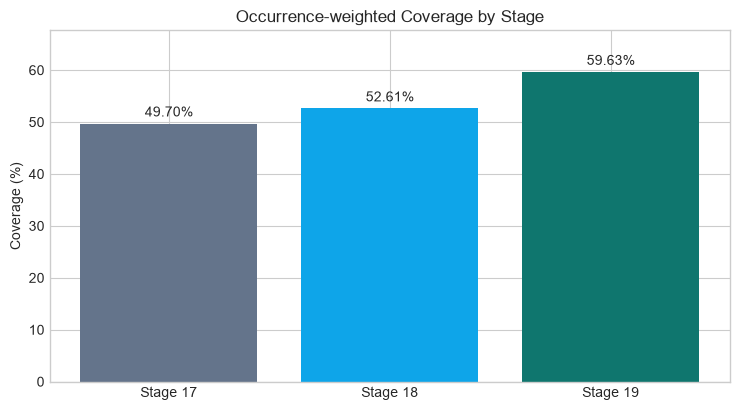

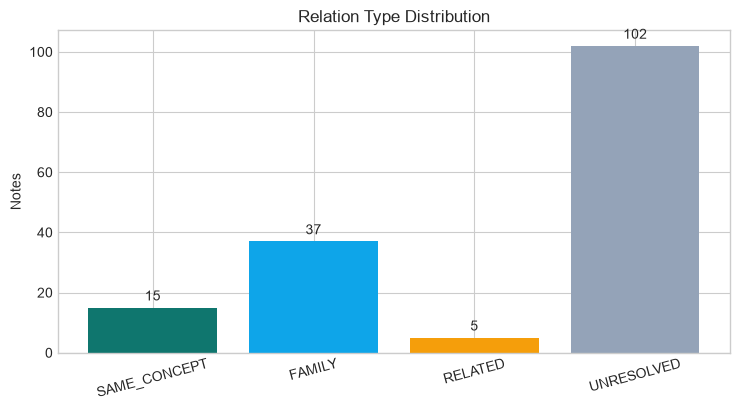

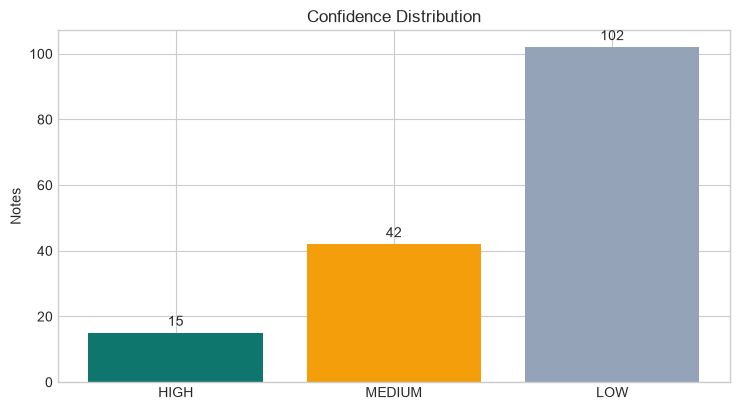

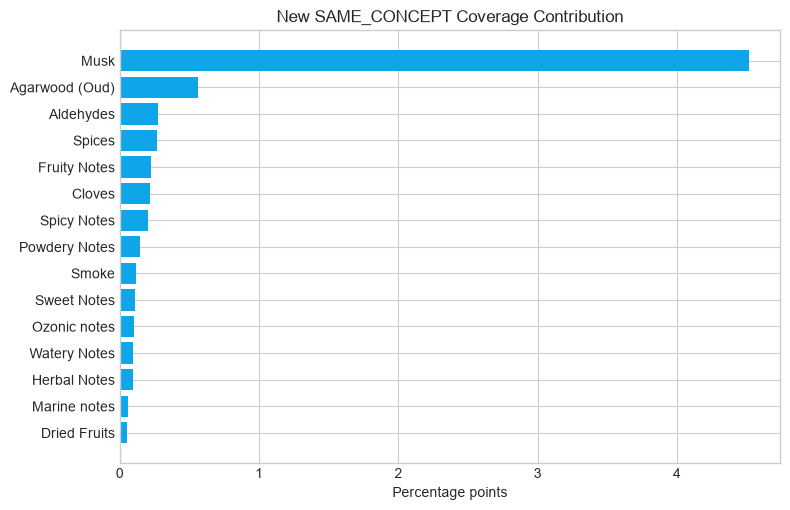

In [7]:
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#64748B", "#0EA5E9", "#0F766E"]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(stage_metrics["stage"], stage_metrics["occurrence_weighted_coverage"] * 100, color=COLORS)
ax.bar_label(bars, fmt="%.2f%%", padding=3)
ax.set_title("Occurrence-weighted Coverage by Stage")
ax.set_ylabel("Coverage (%)")
ax.set_ylim(0, max(stage_metrics["occurrence_weighted_coverage"] * 100) + 8)
plt.tight_layout(); plt.show()

relation_counts = decisions["relation_type"].value_counts().reindex(["SAME_CONCEPT", "FAMILY", "RELATED", "UNRESOLVED"], fill_value=0)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(relation_counts.index, relation_counts.values, color=["#0F766E", "#0EA5E9", "#F59E0B", "#94A3B8"])
ax.bar_label(bars, padding=3)
ax.set_title("Relation Type Distribution")
ax.set_ylabel("Notes")
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

confidence_counts = decisions["confidence"].value_counts().reindex(["HIGH", "MEDIUM", "LOW"], fill_value=0)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar(confidence_counts.index, confidence_counts.values, color=["#0F766E", "#F59E0B", "#94A3B8"])
ax.bar_label(bars, padding=3)
ax.set_title("Confidence Distribution")
ax.set_ylabel("Notes")
plt.tight_layout(); plt.show()

plot_contribution = contribution.head(20).sort_values("coverage_contribution_percentage_point")
fig, ax = plt.subplots(figsize=(8.0, 5.2))
ax.barh(plot_contribution["term"], plot_contribution["coverage_contribution_percentage_point"], color="#0EA5E9")
ax.set_title("New SAME_CONCEPT Coverage Contribution")
ax.set_xlabel("Percentage points")
plt.tight_layout(); plt.show()


## 7. 결과 요약 및 최종 판단

In [8]:
relation_counts = decisions["relation_type"].value_counts()
confidence_counts = decisions["confidence"].value_counts()
m18 = stage_metrics.set_index("stage").loc["Stage 18"]
m19 = stage_metrics.set_index("stage").loc["Stage 19"]
delta_occ_pp = (m19["occurrence_weighted_coverage"] - m18["occurrence_weighted_coverage"]) * 100
delta_perfume_pp = (m19["perfume_level_coverage"] - m18["perfume_level_coverage"]) * 100

top100 = top_comparison.set_index("top_n").loc[100]
top200 = top_comparison.set_index("top_n").loc[200]
critical_unresolved = high_unresolved.head(10)[["note", "perfume_count", "occurrence_count", "relation_type"]]
top_contributors = contribution.head(10)

recommendation = (
    f"Stage 19가 occurrence-weighted coverage를 {delta_occ_pp:.2f}%p 높였지만 Top 100/200 vocabulary coverage가 "
    f"각각 {top100['stage19_vocabulary_coverage']:.2%}/{top200['stage19_vocabulary_coverage']:.2%}이고, "
    "Leather·Orange Blossom·Pink Pepper·Freesia처럼 고빈도 핵심 Note가 남아 있다. 따라서 즉시 전면 "
    "Semantic Bridge로 이동하기보다 이 Note들을 다루는 보완 Knowledge Source를 한 차례 더 확장한 뒤 "
    "Semantic Bridge 파일럿으로 이동한다. FAMILY/RELATED는 Strict Coverage에 넣지 않는다."
)

summary = f"""# Scent Term Dictionary Expansion

## 결과 요약

### 결론

- 검증 Note 수: **{len(decisions):,}**
- SAME_CONCEPT: **{relation_counts.get('SAME_CONCEPT', 0):,}**
- FAMILY: **{relation_counts.get('FAMILY', 0):,}**
- RELATED: **{relation_counts.get('RELATED', 0):,}**
- UNRESOLVED: **{relation_counts.get('UNRESOLVED', 0):,}**
- Stage 18 → Stage 19 occurrence-weighted coverage: **{m18['occurrence_weighted_coverage']:.2%} → {m19['occurrence_weighted_coverage']:.2%} ({delta_occ_pp:+.2f}%p)**
- Stage 18 → Stage 19 perfume-level coverage: **{m18['perfume_level_coverage']:.2%} → {m19['perfume_level_coverage']:.2%} ({delta_perfume_pp:+.2f}%p)**
- 향 용어 사전 확장은 공식 근거가 있는 {len(stage19_added)}개 신규 SAME_CONCEPT에 한해 Strict Coverage를 높였다.

## 핵심 수치

{markdown_table(stage_metrics)}

## 상세

### 1. 분석 목적

Stage 17의 고빈도 unmatched Note를 공식 향 지식으로 검증해 v0.2 사전을 만들고, 추가 사전 확장과 Semantic Bridge 중 다음 단계를 판단했다.

### 2. 검증 대상 선정 기준

- Stage 17 strict match와 Stage 18 P0 8개를 제외했다.
- perfume_count 내림차순으로 정렬한 뒤 occurrence 누적 80%에 필요한 {n_to_80}개와 최대 200개 중 작은 **{target_n}개**를 선택했다.
- 선택된 대상은 제외 후 unmatched occurrence의 **{targets.iloc[-1]['cumulative_unmatched_occurrence_share']:.2%}**를 설명한다.

### 3. 사용한 공식 자료

- IFRA Fragrance Ingredient Glossary April 2020 로컬 PDF 및 그 가공 CSV
- Givaudan 공식 Natural Ingredients 페이지
- IFF 공식 Fragrance Ingredients Compendium
- PubChem은 화학적 동일성 검증에만 허용했으며, 이번 신규 판정에는 사용할 필요가 없었다.
- 검색 snippet, Wikipedia, 커뮤니티, 블로그, 판매 사이트는 Evidence로 사용하지 않았다.

### 4. Relation 판정 결과

{markdown_table(pd.DataFrame({'relation_type': relation_counts.index, 'count': relation_counts.values, 'share': relation_counts.values / len(decisions)}))}

Confidence 분포:

{markdown_table(pd.DataFrame({'confidence': confidence_counts.index, 'count': confidence_counts.values, 'share': confidence_counts.values / len(decisions)}))}

### 5. 주요 SAME_CONCEPT

{markdown_table(decisions.loc[decisions['relation_type'].eq('SAME_CONCEPT'), ['note', 'candidate_term', 'confidence', 'decision_reason']])}

### 6. FAMILY / RELATED 사례

FAMILY는 IFRA의 실제 oil/absolute/extract 등과의 관계만 의미하고 note concept 동일성을 뜻하지 않는다. RELATED도 descriptor 근접성만 기록한다. 두 유형 모두 Strict Coverage에서 제외했다.

### 7. Coverage 변화

- Strict matched Note: {int(m18['strict_matched_note_count'])} → {int(m19['strict_matched_note_count'])}
- Vocabulary: {m18['vocabulary_coverage']:.2%} → {m19['vocabulary_coverage']:.2%}
- Occurrence-weighted: {m18['occurrence_weighted_coverage']:.2%} → {m19['occurrence_weighted_coverage']:.2%}
- Perfume-level: {m18['perfume_level_coverage']:.2%} → {m19['perfume_level_coverage']:.2%}
- Top 100 vocabulary coverage: {top100['stage19_vocabulary_coverage']:.2%}
- Top 200 vocabulary coverage: {top200['stage19_vocabulary_coverage']:.2%}

### 8. Coverage 개선 기여도가 높은 Mapping

{markdown_table(top_contributors)}

### 9. 아직 해결되지 않은 고빈도 Note

{markdown_table(critical_unresolved)}

### 10. Source별 효용

{markdown_table(source_effect)}

IFRA는 모든 신규 대상의 1차 감사 기준과 descriptor/material 후보를 제공했다. Givaudan과 IFF는 일부 핵심 용어의 공식 업계 용례를 보강했다. PubChem은 이번 대상에서 화학적 identity가 필요한 안전한 SAME_CONCEPT 사례가 없어 사용하지 않았다.

### 11. 이번 분석에서 검증된 것

- 표기·문법 차이와 공식 category 문구가 함께 있는 15개 Note는 HIGH SAME_CONCEPT로 자동 활용 가능하다.
- 원료 형태 일치는 Note concept 동일성이 아니며 FAMILY로 분리해야 한다.
- 공식 근거가 없는 고빈도 Note를 억지로 canonicalize하지 않아도 Coverage 증가분을 정직하게 측정할 수 있다.

### 12. 아직 검증되지 않은 것

- 향수 데이터셋의 복합 note concept와 IFRA descriptor 사이의 광범위한 의미 대응
- Orange Blossom/Neroli, Mint/Peppermint, Moss/Oakmoss 같은 개념-원료 관계
- 브랜드·지역·품종이 붙은 원료형 note의 표준 canonicalization

### 13. Semantic Bridge 준비 판단

**{recommendation}**

판단은 vocabulary만이 아니라 occurrence-weighted coverage, Top 100/200 coverage, 고빈도 unresolved의 사업 중요도를 함께 반영했다.

### 14. 다음 단계

1. 고빈도 unresolved에 대해 공식 원료 카탈로그/표준 taxonomy를 추가 검증한다.
2. 다음 확장에서도 HIGH SAME_CONCEPT만 strict mapping으로 승격한다.
3. 별도 Semantic Bridge 파일럿에서는 FAMILY/RELATED를 특징으로 활용하되 정답 label로 간주하지 않는다.
"""

(OUTPUT / "19_scent_term_dictionary_expansion_summary.md").write_text(summary, encoding="utf-8")
display(Markdown(summary))


# Scent Term Dictionary Expansion

## 결과 요약

### 결론

- 검증 Note 수: **159**
- SAME_CONCEPT: **15**
- FAMILY: **37**
- RELATED: **5**
- UNRESOLVED: **102**
- Stage 18 → Stage 19 occurrence-weighted coverage: **52.61% → 59.63% (+7.03%p)**
- Stage 18 → Stage 19 perfume-level coverage: **94.27% → 95.57% (+1.30%p)**
- 향 용어 사전 확장은 공식 근거가 있는 15개 신규 SAME_CONCEPT에 한해 Strict Coverage를 높였다.

## 핵심 수치

| stage | strict_matched_note_count | vocabulary_coverage | occurrence_weighted_coverage | perfume_level_coverage | matched_occurrence_count | total_note_types | total_occurrence_count | total_perfumes |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Stage 17 | 159 | 0.06302021403091558 | 0.4970420397314571 | 0.923110740544228 | 545863 | 2523 | 1098223 | 131930 |
| Stage 18 | 165 | 0.06539833531510107 | 0.5260725736029932 | 0.9427196240430531 | 577745 | 2523 | 1098223 | 131930 |
| Stage 19 | 180 | 0.0713436385255648 | 0.5963360811055678 | 0.9557492609717274 | 654910 | 2523 | 1098223 | 131930 |

## 상세

### 1. 분석 목적

Stage 17의 고빈도 unmatched Note를 공식 향 지식으로 검증해 v0.2 사전을 만들고, 추가 사전 확장과 Semantic Bridge 중 다음 단계를 판단했다.

### 2. 검증 대상 선정 기준

- Stage 17 strict match와 Stage 18 P0 8개를 제외했다.
- perfume_count 내림차순으로 정렬한 뒤 occurrence 누적 80%에 필요한 159개와 최대 200개 중 작은 **159개**를 선택했다.
- 선택된 대상은 제외 후 unmatched occurrence의 **80.01%**를 설명한다.

### 3. 사용한 공식 자료

- IFRA Fragrance Ingredient Glossary April 2020 로컬 PDF 및 그 가공 CSV
- Givaudan 공식 Natural Ingredients 페이지
- IFF 공식 Fragrance Ingredients Compendium
- PubChem은 화학적 동일성 검증에만 허용했으며, 이번 신규 판정에는 사용할 필요가 없었다.
- 검색 snippet, Wikipedia, 커뮤니티, 블로그, 판매 사이트는 Evidence로 사용하지 않았다.

### 4. Relation 판정 결과

| relation_type | count | share |
| --- | --- | --- |
| UNRESOLVED | 102 | 0.6415094339622641 |
| FAMILY | 37 | 0.23270440251572327 |
| SAME_CONCEPT | 15 | 0.09433962264150944 |
| RELATED | 5 | 0.031446540880503145 |

Confidence 분포:

| confidence | count | share |
| --- | --- | --- |
| LOW | 102 | 0.6415094339622641 |
| MEDIUM | 42 | 0.2641509433962264 |
| HIGH | 15 | 0.09433962264150944 |

### 5. 주요 SAME_CONCEPT

| note | candidate_term | confidence | decision_reason |
| --- | --- | --- | --- |
| Musk | Musk-Like | HIGH | OFFICIAL_CATEGORY_EQUIVALENCE: official evidence supports a canonical term-level equivalence. |
| Agarwood (Oud) | Agarwood | HIGH | OFFICIAL_PAIRED_NAMING: official evidence supports a canonical term-level equivalence. |
| Aldehydes | Aldehydic | HIGH | OFFICIAL_GRAMMATICAL_EQUIVALENCE: official evidence supports a canonical term-level equivalence. |
| Spices | Spicy | HIGH | OFFICIAL_CATEGORY_EQUIVALENCE: official evidence supports a canonical term-level equivalence. |
| Fruity Notes | Fruity | HIGH | NOTES_SUFFIX_DESCRIPTOR: official evidence supports a canonical term-level equivalence. |
| Cloves | Clove | HIGH | PLURAL_DESCRIPTOR: official evidence supports a canonical term-level equivalence. |
| Spicy Notes | Spicy | HIGH | NOTES_SUFFIX_DESCRIPTOR: official evidence supports a canonical term-level equivalence. |
| Powdery Notes | Powdery | HIGH | NOTES_SUFFIX_DESCRIPTOR: official evidence supports a canonical term-level equivalence. |
| Smoke | Smoky | HIGH | OFFICIAL_GRAMMATICAL_EQUIVALENCE: official evidence supports a canonical term-level equivalence. |
| Sweet Notes | Sweet | HIGH | NOTES_SUFFIX_DESCRIPTOR: official evidence supports a canonical term-level equivalence. |
| Ozonic notes | Ozonic | HIGH | NOTES_SUFFIX_DESCRIPTOR: official evidence supports a canonical term-level equivalence. |
| Watery Notes | Watery | HIGH | NOTES_SUFFIX_DESCRIPTOR: official evidence supports a canonical term-level equivalence. |
| Herbal Notes | Herbal | HIGH | NOTES_SUFFIX_DESCRIPTOR: official evidence supports a canonical term-level equivalence. |
| Marine notes | Marine | HIGH | NOTES_SUFFIX_DESCRIPTOR: official evidence supports a canonical term-level equivalence. |
| Dried Fruits | Dried-Fruit | HIGH | PLURAL_DESCRIPTOR: official evidence supports a canonical term-level equivalence. |

### 6. FAMILY / RELATED 사례

FAMILY는 IFRA의 실제 oil/absolute/extract 등과의 관계만 의미하고 note concept 동일성을 뜻하지 않는다. RELATED도 descriptor 근접성만 기록한다. 두 유형 모두 Strict Coverage에서 제외했다.

### 7. Coverage 변화

- Strict matched Note: 165 → 180
- Vocabulary: 6.54% → 7.13%
- Occurrence-weighted: 52.61% → 59.63%
- Perfume-level: 94.27% → 95.57%
- Top 100 vocabulary coverage: 68.00%
- Top 200 vocabulary coverage: 53.50%

### 8. Coverage 개선 기여도가 높은 Mapping

| term | canonical_term | occurrence_count | coverage_contribution_percentage_point | cumulative_contribution |
| --- | --- | --- | --- | --- |
| Musk | Musk-Like | 49571 | 4.513746297427754 | 4.513746297427754 |
| Agarwood (Oud) | Agarwood | 6134 | 0.5585386574493523 | 5.072284954877106 |
| Aldehydes | Aldehydic | 3024 | 0.2753539126388721 | 5.347638867515978 |
| Spices | Spicy | 2899 | 0.2639718891336277 | 5.611610756649606 |
| Fruity Notes | Fruity | 2493 | 0.22700307678859394 | 5.8386138334382 |
| Cloves | Clove | 2390 | 0.2176242894202726 | 6.056238122858472 |
| Spicy Notes | Spicy | 2240 | 0.2039658612139793 | 6.260203984072452 |
| Powdery Notes | Powdery | 1604 | 0.1460541256192959 | 6.4062581096917475 |
| Smoke | Smoky | 1236 | 0.11254544841985643 | 6.518803558111604 |
| Sweet Notes | Sweet | 1225 | 0.11154383035139492 | 6.630347388462999 |

### 9. 아직 해결되지 않은 고빈도 Note

| note | perfume_count | occurrence_count | relation_type |
| --- | --- | --- | --- |
| Mandarin Orange | 11646 | 11652 | UNRESOLVED |
| Orange Blossom | 11479 | 11545 | UNRESOLVED |
| Leather | 10626 | 10754 | RELATED |
| Pink Pepper | 10387 | 10395 | UNRESOLVED |
| Lily-of-the-Valley | 7339 | 7366 | UNRESOLVED |
| Freesia | 5683 | 5696 | UNRESOLVED |
| Black Pepper | 4795 | 4807 | UNRESOLVED |
| Mint | 4605 | 4627 | UNRESOLVED |
| Moss | 4302 | 4310 | RELATED |
| Woodsy Notes | 3240 | 3250 | UNRESOLVED |

### 10. Source별 효용

| source_group | evidence_count | supported_term_count | same_concept_support_count | family_support_count | resolved_or_candidate_count |
| --- | --- | --- | --- | --- | --- |
| IFRA only | 156 | 156 | 13 | 36 | 54 |
| Givaudan | 2 | 2 | 1 | 1 | 2 |
| IFF | 1 | 1 | 1 | 0 | 1 |
| PubChem | 0 | 0 | 0 | 0 | 0 |
| Multiple Sources | 6 | 3 | 2 | 1 | 3 |

IFRA는 모든 신규 대상의 1차 감사 기준과 descriptor/material 후보를 제공했다. Givaudan과 IFF는 일부 핵심 용어의 공식 업계 용례를 보강했다. PubChem은 이번 대상에서 화학적 identity가 필요한 안전한 SAME_CONCEPT 사례가 없어 사용하지 않았다.

### 11. 이번 분석에서 검증된 것

- 표기·문법 차이와 공식 category 문구가 함께 있는 15개 Note는 HIGH SAME_CONCEPT로 자동 활용 가능하다.
- 원료 형태 일치는 Note concept 동일성이 아니며 FAMILY로 분리해야 한다.
- 공식 근거가 없는 고빈도 Note를 억지로 canonicalize하지 않아도 Coverage 증가분을 정직하게 측정할 수 있다.

### 12. 아직 검증되지 않은 것

- 향수 데이터셋의 복합 note concept와 IFRA descriptor 사이의 광범위한 의미 대응
- Orange Blossom/Neroli, Mint/Peppermint, Moss/Oakmoss 같은 개념-원료 관계
- 브랜드·지역·품종이 붙은 원료형 note의 표준 canonicalization

### 13. Semantic Bridge 준비 판단

**Stage 19가 occurrence-weighted coverage를 7.03%p 높였지만 Top 100/200 vocabulary coverage가 각각 68.00%/53.50%이고, Leather·Orange Blossom·Pink Pepper·Freesia처럼 고빈도 핵심 Note가 남아 있다. 따라서 즉시 전면 Semantic Bridge로 이동하기보다 이 Note들을 다루는 보완 Knowledge Source를 한 차례 더 확장한 뒤 Semantic Bridge 파일럿으로 이동한다. FAMILY/RELATED는 Strict Coverage에 넣지 않는다.**

판단은 vocabulary만이 아니라 occurrence-weighted coverage, Top 100/200 coverage, 고빈도 unresolved의 사업 중요도를 함께 반영했다.

### 14. 다음 단계

1. 고빈도 unresolved에 대해 공식 원료 카탈로그/표준 taxonomy를 추가 검증한다.
2. 다음 확장에서도 HIGH SAME_CONCEPT만 strict mapping으로 승격한다.
3. 별도 Semantic Bridge 파일럿에서는 FAMILY/RELATED를 특징으로 활용하되 정답 label로 간주하지 않는다.


In [9]:
expected_outputs = [
    ROOT / "19_scent_term_dictionary_expansion.ipynb",
    KNOWLEDGE / "scent_term_dictionary_v0.2.csv",
    KNOWLEDGE / "scent_term_evidence_v0.2.csv",
    OUTPUT / "19_validation_target_notes.csv",
    OUTPUT / "19_scent_term_expansion_decisions.csv",
    OUTPUT / "19_top_note_coverage_comparison.csv",
    OUTPUT / "19_high_frequency_unresolved_notes.csv",
    OUTPUT / "19_mapping_coverage_contribution.csv",
    OUTPUT / "19_scent_term_dictionary_expansion_summary.md",
]

assert len(targets) == target_n == 159
assert set(decisions["note"]) == set(targets["note"])
assert decisions["evidence_count"].ge(1).all()
assert decisions.loc[~decisions["manual_review_required"], "relation_type"].eq("SAME_CONCEPT").all()
assert decisions.loc[~decisions["manual_review_required"], "confidence"].eq("HIGH").all()
assert len(contribution) == len(stage19_added)
assert len(high_unresolved) == min(50, decisions["relation_type"].isin(["RELATED", "UNRESOLVED"]).sum())
assert evidence_v02.iloc[:len(evidence_v01)][evidence_v01.columns].astype(str).equals(evidence_v01.astype(str))
assert all(path.exists() for path in expected_outputs)

print("Validation passed.")
print(f"Targets={len(targets)}, SAME={relation_counts.get('SAME_CONCEPT', 0)}, FAMILY={relation_counts.get('FAMILY', 0)}, RELATED={relation_counts.get('RELATED', 0)}, UNRESOLVED={relation_counts.get('UNRESOLVED', 0)}")
print(f"Stage18→19 occurrence coverage: {m18['occurrence_weighted_coverage']:.4%} → {m19['occurrence_weighted_coverage']:.4%}")
print(f"Recommendation: {recommendation}")
print("Artifacts:")
for path in expected_outputs:
    print("-", path.relative_to(ROOT))


Validation passed.
Targets=159, SAME=15, FAMILY=37, RELATED=5, UNRESOLVED=102
Stage18→19 occurrence coverage: 52.6073% → 59.6336%
Recommendation: Stage 19가 occurrence-weighted coverage를 7.03%p 높였지만 Top 100/200 vocabulary coverage가 각각 68.00%/53.50%이고, Leather·Orange Blossom·Pink Pepper·Freesia처럼 고빈도 핵심 Note가 남아 있다. 따라서 즉시 전면 Semantic Bridge로 이동하기보다 이 Note들을 다루는 보완 Knowledge Source를 한 차례 더 확장한 뒤 Semantic Bridge 파일럿으로 이동한다. FAMILY/RELATED는 Strict Coverage에 넣지 않는다.
Artifacts:
- 19_scent_term_dictionary_expansion.ipynb
- data\scent_knowledge\scent_term_dictionary_v0.2.csv
- data\scent_knowledge\scent_term_evidence_v0.2.csv
- analysis_outputs\19_validation_target_notes.csv
- analysis_outputs\19_scent_term_expansion_decisions.csv
- analysis_outputs\19_top_note_coverage_comparison.csv
- analysis_outputs\19_high_frequency_unresolved_notes.csv
- analysis_outputs\19_mapping_coverage_contribution.csv
- analysis_outputs\19_scent_term_dictionary_expansion_summary.md
